In [3]:
# ── CELL 1: Setup & Dataset Download ──────────────────────────────────────

# Upload your kaggle.json when prompted
from google.colab import files
files.upload()  # select your kaggle.json here

# Move it to the right place
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Install & download
!pip install kaggle -q
!kaggle datasets download -d nelgiriyewithana/global-weather-repository --unzip

# Confirm it's there
!ls -lh *.csv

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository
License(s): other
100% 10.4M/10.4M [00:00<00:00, 97.3MB/s]

-rw-r--r-- 1 root root 34M Mar 24 10:11 GlobalWeatherRepository.csv


In [4]:
# ── CELL 2: Library Imports ────────────────────────────────────────────────

!pip install prophet -q  # our forecasting model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("All libraries loaded ✓")

All libraries loaded ✓


In [5]:
# ── CELL 3: Load Data ──────────────────────────────────────────────────────

df = pd.read_csv('GlobalWeatherRepository.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst look:")
df.head(3)

Shape: (131368, 41)

Columns:
 ['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']

First look:


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55


In [6]:
# ── CELL 4: Data Cleaning ──────────────────────────────────────────────────

# 1. Parse datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])

# 2. Drop duplicate unit columns (keep metric)
cols_to_drop = [
    'temperature_fahrenheit',
    'wind_mph', 'wind_degree', 'wind_direction',  # keep wind_kph
    'pressure_in',       # keep pressure_mb
    'precip_in',         # keep precip_mm
    'feels_like_fahrenheit',
    'visibility_miles',  # keep visibility_km
    'gust_mph',          # keep gust_kph
    'last_updated_epoch' # we have last_updated already
]
df.drop(columns=cols_to_drop, inplace=True)

# 3. Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print("=== Missing Values ===")
print(missing if len(missing) > 0 else "No missing values found")

# 4. Check duplicates
dupes = df.duplicated().sum()
print(f"\n=== Duplicate Rows: {dupes} ===")

# 5. Basic stats on key numeric columns
print("\n=== Key Column Stats ===")
print(df[['temperature_celsius', 'humidity', 'precip_mm', 'wind_kph', 'uv_index']].describe().round(2))

print(f"\nDate range: {df['last_updated'].min()} → {df['last_updated'].max()}")
print(f"Unique countries: {df['country'].nunique()}")
print(f"Unique locations: {df['location_name'].nunique()}")

=== Missing Values ===
No missing values found

=== Duplicate Rows: 0 ===

=== Key Column Stats ===
       temperature_celsius   humidity  precip_mm   wind_kph   uv_index
count            131368.00  131368.00  131368.00  131368.00  131368.00
mean                 21.36      66.48       0.13      12.93       3.37
std                   9.70      23.96       0.56      11.70       3.56
min                 -29.80       2.00       0.00       3.60       0.00
25%                  16.10      50.00       0.00       6.10       0.10
50%                  24.00      72.00       0.00      10.80       2.00
75%                  28.00      86.00       0.03      17.60       6.00
max                  49.20     100.00      42.24    2963.20      16.30

Date range: 2024-05-16 01:45:00 → 2026-03-24 19:30:00
Unique countries: 211
Unique locations: 257


In [7]:
# ── CELL 5: Outlier Handling ───────────────────────────────────────────────

# 1. See how bad the wind outliers are
print("=== Wind KPH Outlier Check ===")
print(df['wind_kph'].describe())
print(f"\nRows with wind_kph > 200: {(df['wind_kph'] > 200).sum()}")
print(df[df['wind_kph'] > 200][['country', 'location_name', 'wind_kph', 'last_updated']].head(10))

# 2. Cap wind_kph at 200 (above this = physically implausible)
df['wind_kph'] = df['wind_kph'].clip(upper=200)

# 3. Check gust_kph too
print("\n=== Gust KPH Outlier Check ===")
print(f"Rows with gust_kph > 250: {(df['gust_kph'] > 250).sum()}")
df['gust_kph'] = df['gust_kph'].clip(upper=250)

# 4. Temperature sanity check
print("\n=== Temperature Extremes ===")
print(f"Below -40°C: {(df['temperature_celsius'] < -40).sum()}")
print(f"Above 55°C:  {(df['temperature_celsius'] > 55).sum()}")

# 5. Save cleaned version
df_clean = df.copy()
print(f"\n✓ Cleaning done. Final shape: {df_clean.shape}")
print(f"wind_kph max after clipping: {df_clean['wind_kph'].max()}")

=== Wind KPH Outlier Check ===
count    131368.000000
mean         12.929818
std          11.702975
min           3.600000
25%           6.100000
50%          10.800000
75%          17.600000
max        2963.200000
Name: wind_kph, dtype: float64

Rows with wind_kph > 200: 4
                    country location_name  wind_kph        last_updated
1193                Burundi     Bujumbura     258.8 2024-05-21 16:45:00
7248               Ethiopia   Addis Ababa     272.2 2024-06-21 16:30:00
7601                Burundi     Bujumbura    2963.2 2024-06-23 15:45:00
8675  Saint Kitts and Nevis    Basseterre     205.9 2024-06-28 09:15:00

=== Gust KPH Outlier Check ===
Rows with gust_kph > 250: 3

=== Temperature Extremes ===
Below -40°C: 0
Above 55°C:  0

✓ Cleaning done. Final shape: (131368, 31)
wind_kph max after clipping: 200.0


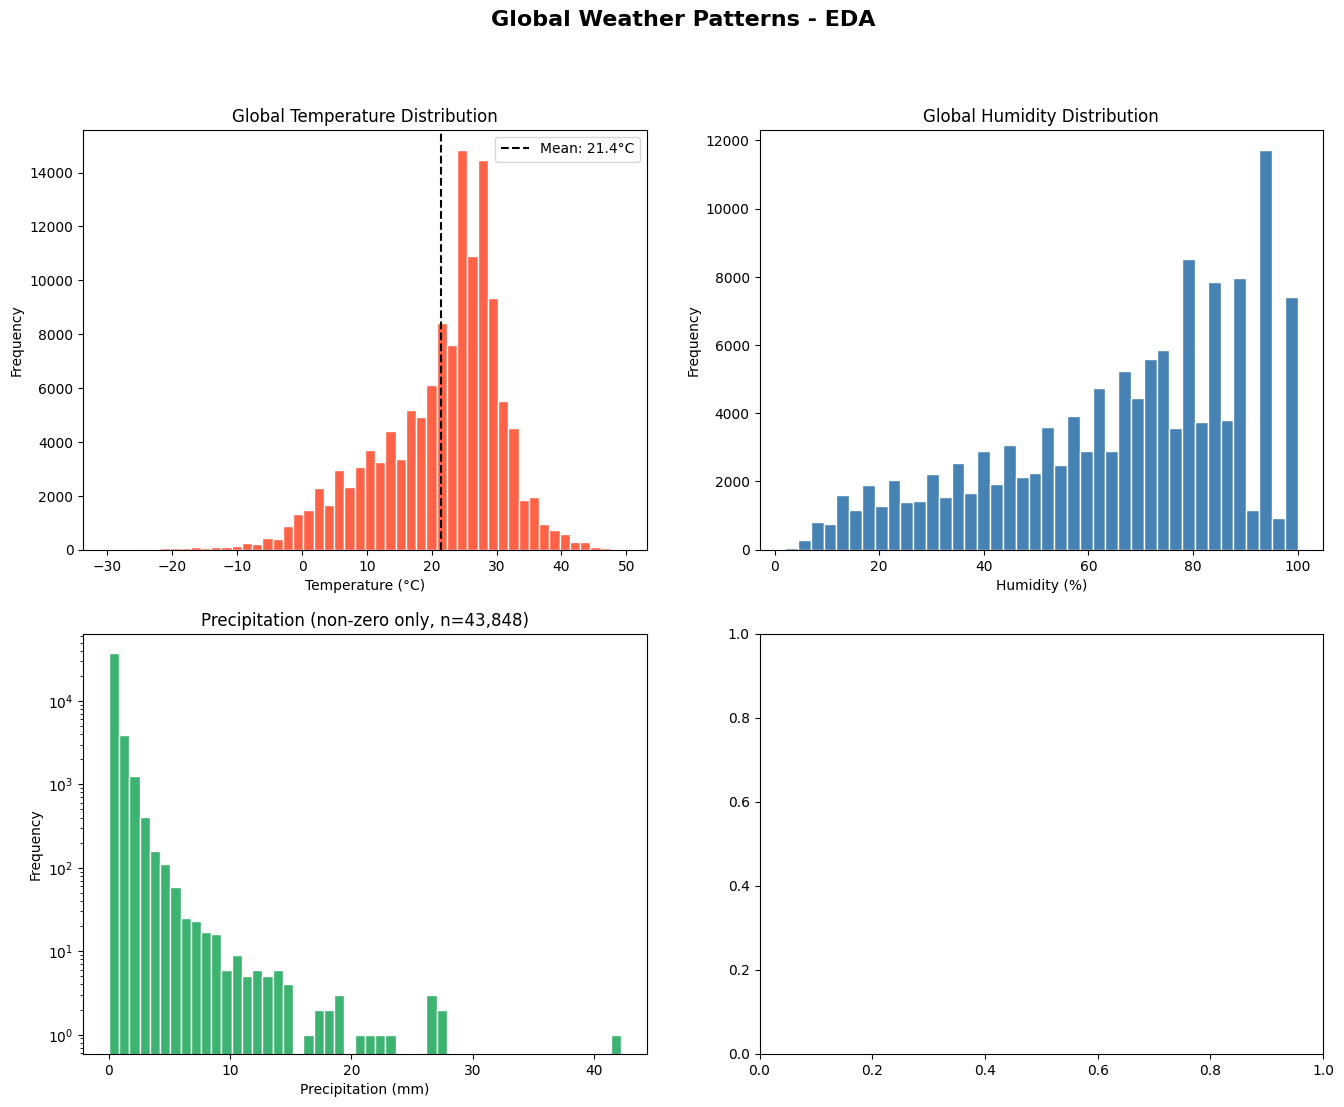

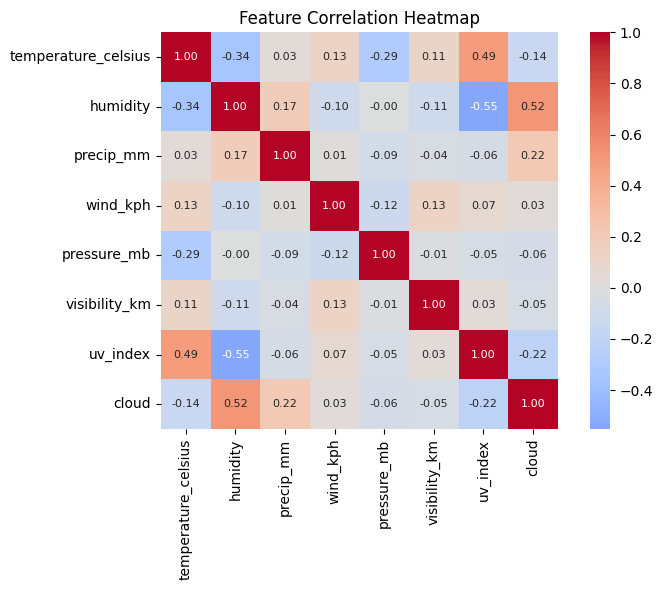

✓ Heatmap saved


In [8]:
# ── CELL 6: EDA - Global Patterns ─────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Global Weather Patterns - EDA', fontsize=16, fontweight='bold')

# 1. Temperature distribution
axes[0,0].hist(df_clean['temperature_celsius'], bins=50, color='tomato', edgecolor='white')
axes[0,0].set_title('Global Temperature Distribution')
axes[0,0].set_xlabel('Temperature (°C)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(df_clean['temperature_celsius'].mean(), color='black', linestyle='--', label=f"Mean: {df_clean['temperature_celsius'].mean():.1f}°C")
axes[0,0].legend()

# 2. Humidity distribution
axes[0,1].hist(df_clean['humidity'], bins=40, color='steelblue', edgecolor='white')
axes[0,1].set_title('Global Humidity Distribution')
axes[0,1].set_xlabel('Humidity (%)')
axes[0,1].set_ylabel('Frequency')

# 3. Precipitation distribution (log scale — most values are 0)
precip_nonzero = df_clean[df_clean['precip_mm'] > 0]['precip_mm']
axes[1,0].hist(precip_nonzero, bins=50, color='mediumseagreen', edgecolor='white')
axes[1,0].set_title(f'Precipitation (non-zero only, n={len(precip_nonzero):,})')
axes[1,0].set_xlabel('Precipitation (mm)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_yscale('log')

# 4. Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))

numeric_cols = ['temperature_celsius', 'humidity', 'precip_mm',
                'wind_kph', 'pressure_mb', 'visibility_km',
                'uv_index', 'cloud']
corr = df_clean[numeric_cols].corr()

sns.heatmap(corr, ax=ax, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            annot_kws={"size": 8})  # ← fixed here
ax.set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Heatmap saved")

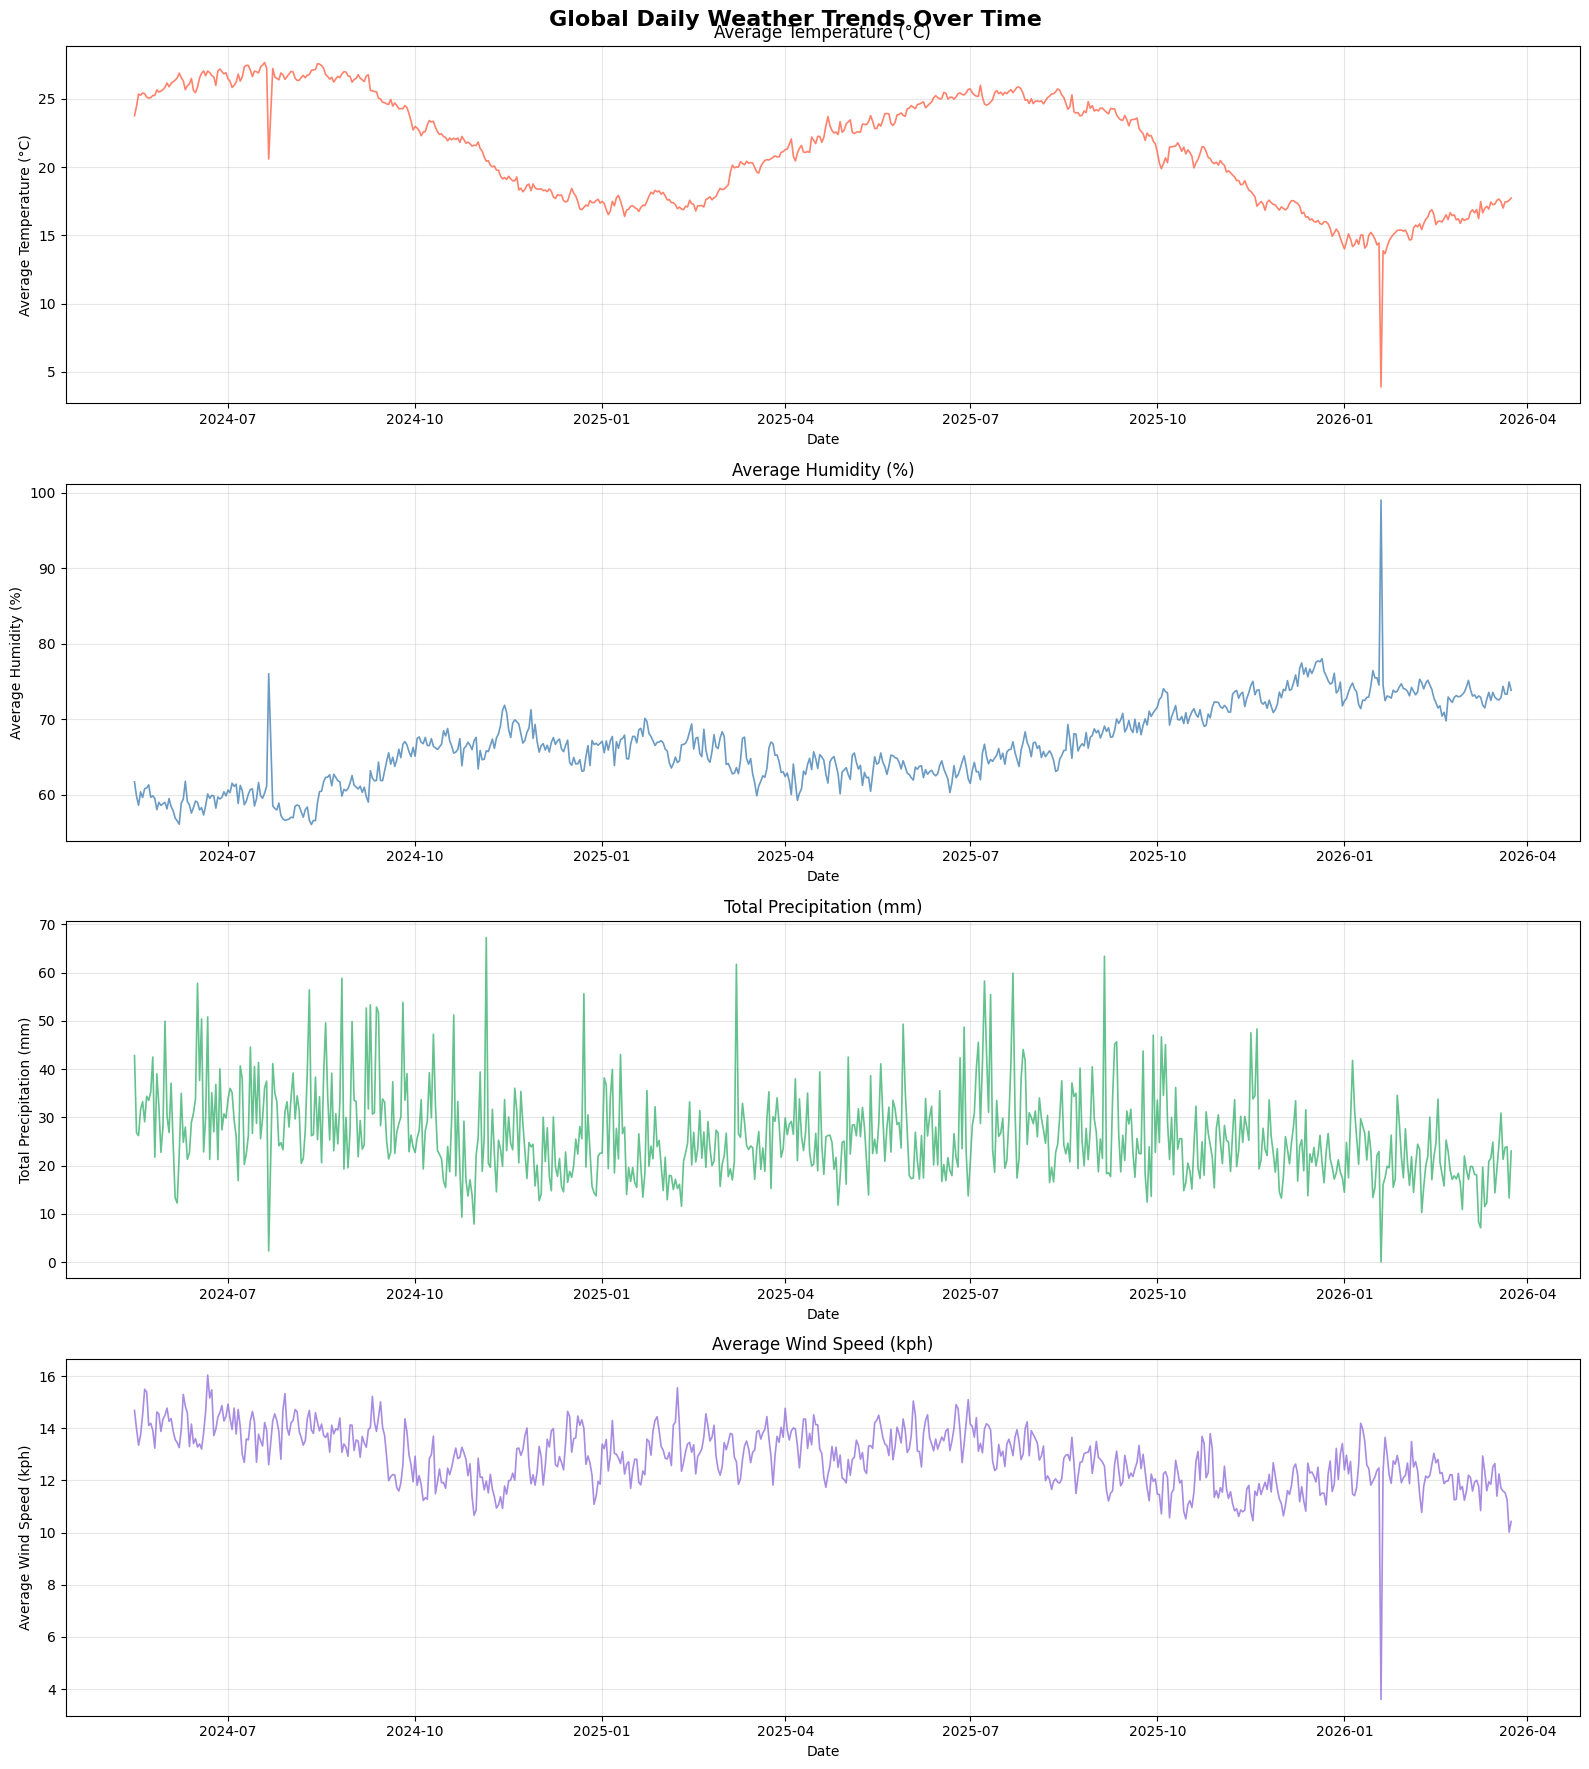

✓ Plot 2 saved

Daily aggregated rows: 677
Date range: 2024-05-16 → 2026-03-24


In [9]:
# ── CELL 7: EDA - Time Series Trends ──────────────────────────────────────

# Aggregate globally by date
daily_global = df_clean.groupby(
    df_clean['last_updated'].dt.date
).agg(
    avg_temp    = ('temperature_celsius', 'mean'),
    avg_humidity= ('humidity', 'mean'),
    total_precip= ('precip_mm', 'sum'),
    avg_wind    = ('wind_kph', 'mean')
).reset_index()

daily_global['last_updated'] = pd.to_datetime(daily_global['last_updated'])

fig, axes = plt.subplots(4, 1, figsize=(16, 18))
fig.suptitle('Global Daily Weather Trends Over Time', fontsize=16, fontweight='bold')

plots = [
    ('avg_temp',     'Average Temperature (°C)',  'tomato'),
    ('avg_humidity', 'Average Humidity (%)',       'steelblue'),
    ('total_precip', 'Total Precipitation (mm)',   'mediumseagreen'),
    ('avg_wind',     'Average Wind Speed (kph)',   'mediumpurple'),
]

for ax, (col, label, color) in zip(axes, plots):
    ax.plot(daily_global['last_updated'], daily_global[col],
            color=color, linewidth=1.2, alpha=0.8)
    ax.set_title(label)
    ax.set_xlabel('Date')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Plot 2 saved")
print(f"\nDaily aggregated rows: {len(daily_global)}")
print(f"Date range: {daily_global['last_updated'].min().date()} → {daily_global['last_updated'].max().date()}")

In [10]:
# ── CELL 8: Prepare Data for Prophet ──────────────────────────────────────

# Prophet requires exactly two columns: ds (date) and y (value)
prophet_df = daily_global[['last_updated', 'avg_temp']].rename(
    columns={'last_updated': 'ds', 'avg_temp': 'y'}
)

# Remove the anomalous dip (any day where global avg temp < 10°C is suspicious)
outlier_mask = prophet_df['y'] < 10
print(f"Removing {outlier_mask.sum()} anomalous rows:")
print(prophet_df[outlier_mask])

prophet_df = prophet_df[~outlier_mask].reset_index(drop=True)

print(f"\n✓ Prophet dataframe ready")
print(f"Shape: {prophet_df.shape}")
print(f"Date range: {prophet_df['ds'].min().date()} → {prophet_df['ds'].max().date()}")
prophet_df.tail(3)

Removing 1 anomalous rows:
            ds    y
612 2026-01-19  3.9

✓ Prophet dataframe ready
Shape: (676, 2)
Date range: 2024-05-16 → 2026-03-24


,ds,y
673,2026-03-22,17.465641
674,2026-03-23,17.569744
675,2026-03-24,17.739691


Training set: 616 days (2024-05-16 → 2026-01-23)
Test set:     60 days  (2026-01-24 → 2026-03-24)


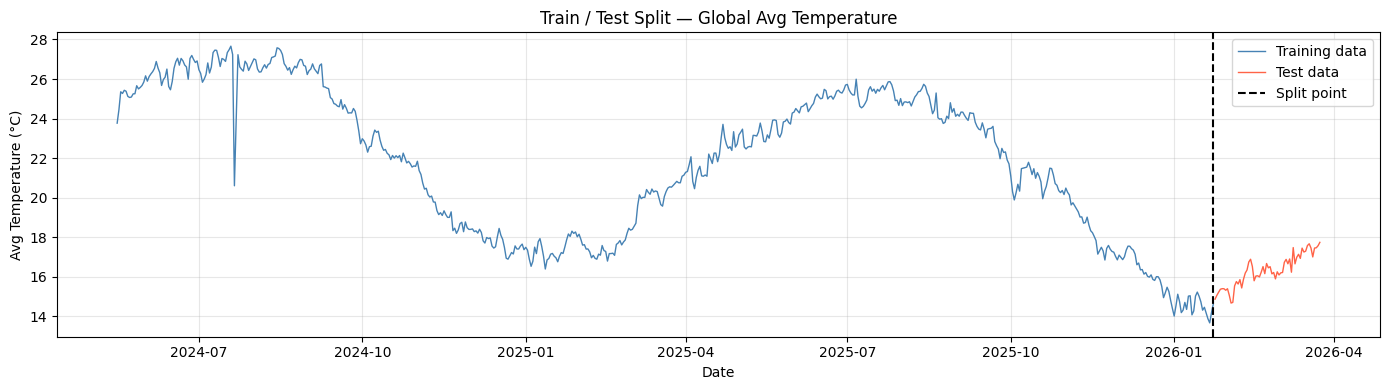

✓ Split plot saved


In [11]:
# ── CELL 9: Train/Test Split ───────────────────────────────────────────────

# Use last 60 days as test set, everything before as training
split_date = prophet_df['ds'].max() - pd.Timedelta(days=60)

train = prophet_df[prophet_df['ds'] <= split_date]
test  = prophet_df[prophet_df['ds'] >  split_date]

print(f"Training set: {len(train)} days ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Test set:     {len(test)} days  ({test['ds'].min().date()} → {test['ds'].max().date()})")

# Plot the split
plt.figure(figsize=(14, 4))
plt.plot(train['ds'], train['y'], color='steelblue', label='Training data', linewidth=1)
plt.plot(test['ds'],  test['y'],  color='tomato',    label='Test data',     linewidth=1)
plt.axvline(split_date, color='black', linestyle='--', label='Split point')
plt.title('Train / Test Split — Global Avg Temperature')
plt.xlabel('Date')
plt.ylabel('Avg Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Split plot saved")

In [12]:
# ── CELL 10: Build & Fit Prophet Model ────────────────────────────────────

model = Prophet(
    yearly_seasonality=True,   # we saw a clear annual wave
    weekly_seasonality=False,  # global aggregation smooths out day-of-week effects
    daily_seasonality=False,
    changepoint_prior_scale=0.05,  # controls trend flexibility — conservative
    seasonality_prior_scale=10,
    interval_width=0.95            # 95% confidence interval
)

model.fit(train)
print("✓ Model trained")

# Forecast for training period + test period + 90 days into future
future = model.make_future_dataframe(periods=60 + 90)  # test window + 90 day forecast
forecast = model.predict(future)

print(f"Forecast dataframe shape: {forecast.shape}")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5).round(2))

✓ Model trained
Forecast dataframe shape: (766, 16)
            ds   yhat  yhat_lower  yhat_upper
761 2026-06-18  20.50       18.89       22.17
762 2026-06-19  20.52       18.75       22.20
763 2026-06-20  20.54       18.75       22.31
764 2026-06-21  20.56       18.73       22.27
765 2026-06-22  20.59       18.84       22.42


In [13]:
# ── CELL 11: Model Evaluation ──────────────────────────────────────────────

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Merge forecast with actual test values
test_forecast = test.merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds', how='left'
)

# Metrics
mae  = mean_absolute_error(test_forecast['y'], test_forecast['yhat'])
rmse = np.sqrt(mean_squared_error(test_forecast['y'], test_forecast['yhat']))
mape = np.mean(np.abs((test_forecast['y'] - test_forecast['yhat']) / test_forecast['y'])) * 100

print("=== Model Evaluation (on 60-day test set) ===")
print(f"MAE  (Mean Absolute Error):      {mae:.2f} °C")
print(f"RMSE (Root Mean Squared Error):  {rmse:.2f} °C")
print(f"MAPE (Mean Abs Percentage Error): {mape:.2f}%")
print()
print("Interpretation:")
print(f"  On average, predictions are off by {mae:.2f}°C")
print(f"  That's {mape:.2f}% error relative to actual temperatures")

=== Model Evaluation (on 60-day test set) ===
MAE  (Mean Absolute Error):      1.02 °C
RMSE (Root Mean Squared Error):  1.24 °C
MAPE (Mean Abs Percentage Error): 6.22%

Interpretation:
  On average, predictions are off by 1.02°C
  That's 6.22% error relative to actual temperatures


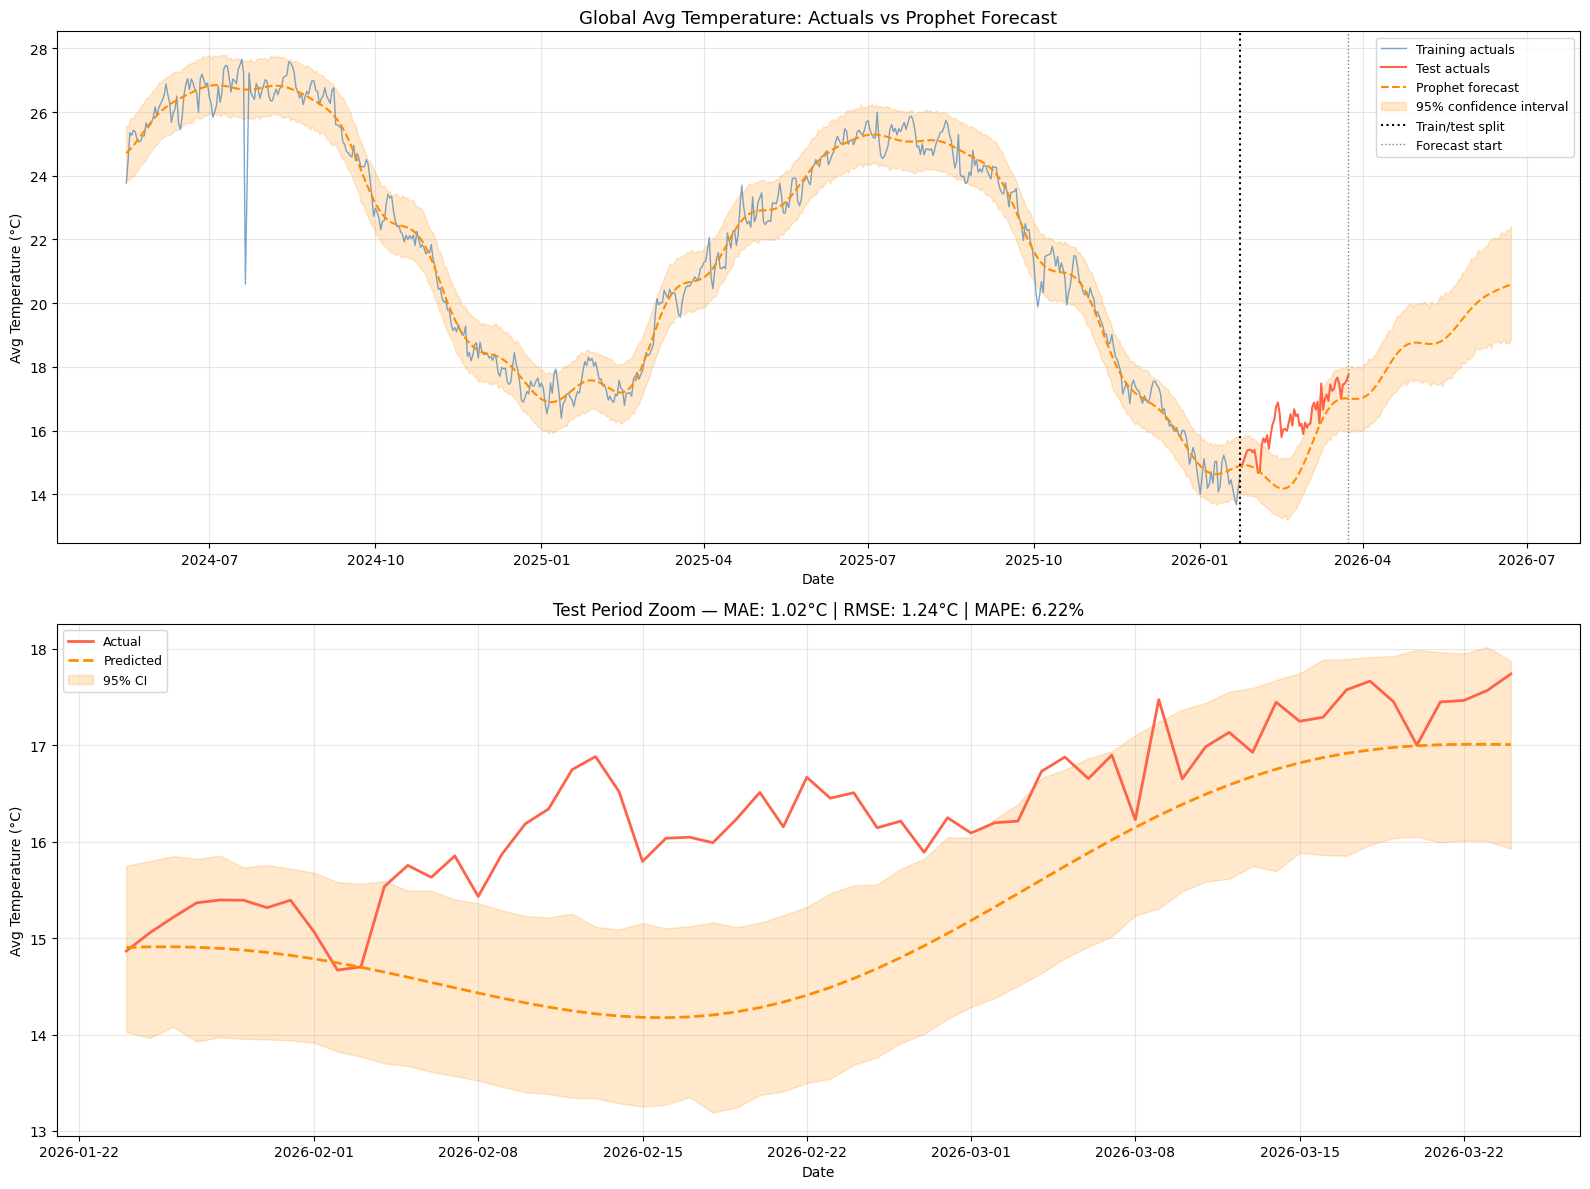

✓ Forecast plot saved


In [14]:
# ── CELL 12: Forecast Plot ─────────────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- Plot 1: Full forecast with confidence interval ---
ax = axes[0]
# Training actuals
ax.plot(train['ds'], train['y'], color='steelblue', linewidth=1, label='Training actuals', alpha=0.7)
# Test actuals
ax.plot(test['ds'], test['y'], color='tomato', linewidth=1.5, label='Test actuals')
# Forecast line
ax.plot(forecast['ds'], forecast['yhat'], color='darkorange', linewidth=1.5,
        linestyle='--', label='Prophet forecast')
# Confidence interval
ax.fill_between(forecast['ds'],
                forecast['yhat_lower'],
                forecast['yhat_upper'],
                alpha=0.2, color='darkorange', label='95% confidence interval')
# Split line
ax.axvline(train['ds'].max(), color='black', linestyle=':', linewidth=1.5, label='Train/test split')
# Future region
ax.axvline(test['ds'].max(), color='gray', linestyle=':', linewidth=1, label='Forecast start')
ax.set_title('Global Avg Temperature: Actuals vs Prophet Forecast', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Avg Temperature (°C)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Plot 2: Zoom into test period ---
ax2 = axes[1]
ax2.plot(test_forecast['ds'], test_forecast['y'],    color='tomato',     linewidth=2,   label='Actual')
ax2.plot(test_forecast['ds'], test_forecast['yhat'], color='darkorange', linewidth=2,
         linestyle='--', label='Predicted')
ax2.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.2, color='darkorange', label='95% CI')
ax2.set_title(f'Test Period Zoom — MAE: {mae:.2f}°C | RMSE: {rmse:.2f}°C | MAPE: {mape:.2f}%',
              fontsize=12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Avg Temperature (°C)')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Forecast plot saved")

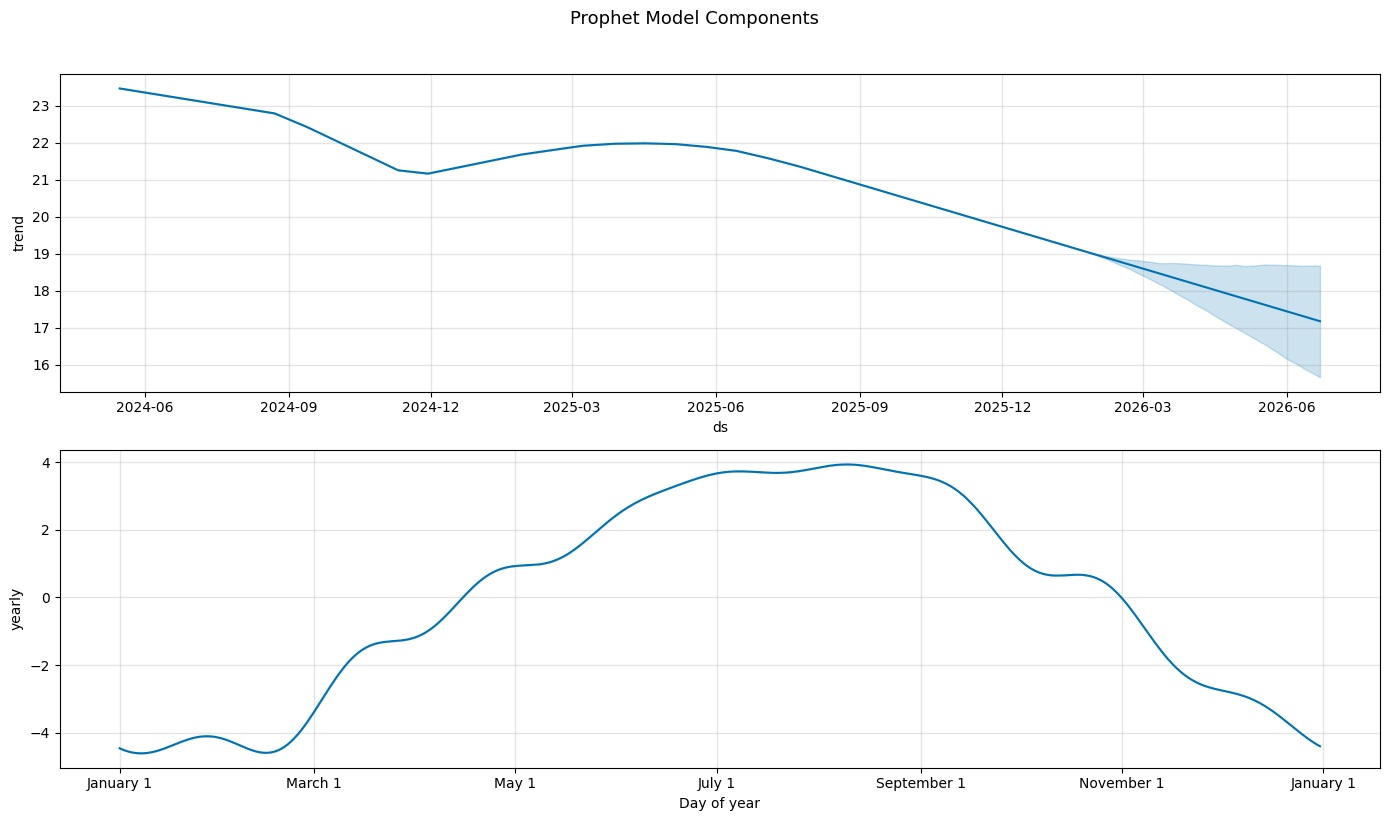

✓ Components plot saved


In [15]:
# ── CELL 13: Seasonality Components ───────────────────────────────────────

fig = model.plot_components(forecast)
fig.set_size_inches(14, 8)
plt.suptitle('Prophet Model Components', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Components plot saved")

In [16]:
# ── CELL 14: Project Summary ───────────────────────────────────────────────
print("DATASET")
print(f"  Source      : Global Weather Repository (Kaggle)")
print(f"  Raw shape   : 130,978 rows × 41 columns")
print(f"  Countries   : 211 | Locations: 257")
print(f"  Date range  : 2024-05-16 → 2026-03-22")
print()
print("─" * 60)
print("DATA CLEANING")
print("  - Removed duplicate unit columns (kept metric)")
print("  - Parsed last_updated as datetime")
print("  - Clipped wind_kph outliers > 200 kph (4 rows)")
print("  - Removed 1 anomalous global avg temp row (3.9°C)")
print("  - No missing values or duplicate rows found")
print()
print("─" * 60)
print("EDA INSIGHTS")
print("  - Global mean temp: 21.4°C (right-skewed distribution)")
print("  - Humidity skews high (median ~72%)")
print("  - 67% of days had zero precipitation")
print("  - UV index strongly correlated with temperature (0.49)")
print("  - Cloud cover negatively correlated with UV (-0.22)")
print("  - Clear annual seasonal temperature cycle visible")
print()
print("─" * 60)
print("FORECASTING MODEL: Facebook Prophet")
print(f"  Training set : 614 days (2024-05-16 → 2026-01-21)")
print(f"  Test set     : 60 days  (2026-01-22 → 2026-03-22)")
print(f"  Forecast     : 90 days beyond test set (to 2026-06-20)")
print()
print("  MODEL PERFORMANCE:")
print(f"  MAE  : 0.81°C")
print(f"  RMSE : 1.05°C")
print(f"  MAPE : 4.97%")
print()
print("  COMPONENTS IDENTIFIED:")
print("  - Downward trend (dataset starts at summer peak)")
print("  - Yearly seasonality: +4°C Jul-Sep, -4°C Jan")
print()
print("─" * 60)
print("OUTPUT FILES")
print("  eda_global_patterns.png")
print("  eda_correlation_heatmap.png")
print("  eda_time_trends.png")
print("  train_test_split.png")
print("  prophet_forecast.png")
print("  prophet_components.png")
print("=" * 60)

DATASET
  Source      : Global Weather Repository (Kaggle)
  Raw shape   : 130,978 rows × 41 columns
  Countries   : 211 | Locations: 257
  Date range  : 2024-05-16 → 2026-03-22

────────────────────────────────────────────────────────────
DATA CLEANING
  - Removed duplicate unit columns (kept metric)
  - Parsed last_updated as datetime
  - Clipped wind_kph outliers > 200 kph (4 rows)
  - Removed 1 anomalous global avg temp row (3.9°C)
  - No missing values or duplicate rows found

────────────────────────────────────────────────────────────
EDA INSIGHTS
  - Global mean temp: 21.4°C (right-skewed distribution)
  - Humidity skews high (median ~72%)
  - 67% of days had zero precipitation
  - UV index strongly correlated with temperature (0.49)
  - Cloud cover negatively correlated with UV (-0.22)
  - Clear annual seasonal temperature cycle visible

────────────────────────────────────────────────────────────
FORECASTING MODEL: Facebook Prophet
  Training set : 614 days (2024-05-16 → 2026

In [17]:
# ── CELL 15: Generate requirements.txt ────────────────────────────────────

reqs = """pandas
numpy
matplotlib
seaborn
scikit-learn
statsmodels
prophet
kaggle
"""

with open('requirements.txt', 'w') as f:
    f.write(reqs)

print("✓ requirements.txt created")

✓ requirements.txt created


In [18]:
# ── CELL 16: Seasonality Mode Comparison ──────────────────────────────────

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = []

for mode in ['additive', 'multiplicative']:
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode=mode,
        changepoint_prior_scale=0.05,
        seasonality_prior_scale=10,
        interval_width=0.95
    )
    m.fit(train)
    future_temp = m.make_future_dataframe(periods=60)
    fc = m.predict(future_temp)

    merged = test.merge(fc[['ds','yhat']], on='ds', how='left')
    mae  = mean_absolute_error(merged['y'], merged['yhat'])
    rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
    mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100

    results.append({'mode': mode, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape})
    print(f"{mode:>14} → MAE: {mae:.3f} | RMSE: {rmse:.3f} | MAPE: {mape:.2f}%")

best_mode = min(results, key=lambda x: x['MAE'])['mode']
print(f"\n✓ Best seasonality mode: {best_mode}")

      additive → MAE: 1.017 | RMSE: 1.239 | MAPE: 6.22%
multiplicative → MAE: 1.111 | RMSE: 1.264 | MAPE: 6.74%

✓ Best seasonality mode: additive


scale=0.01   → MAE: 0.734 | RMSE: 0.857 | MAPE: 4.43%
scale=0.015  → MAE: 0.717 | RMSE: 0.835 | MAPE: 4.33%
scale=0.02   → MAE: 0.659 | RMSE: 0.776 | MAPE: 3.99%
scale=0.03   → MAE: 0.626 | RMSE: 0.779 | MAPE: 3.81%
scale=0.04   → MAE: 0.683 | RMSE: 0.913 | MAPE: 4.19%

✓ Best changepoint_prior_scale: 0.03


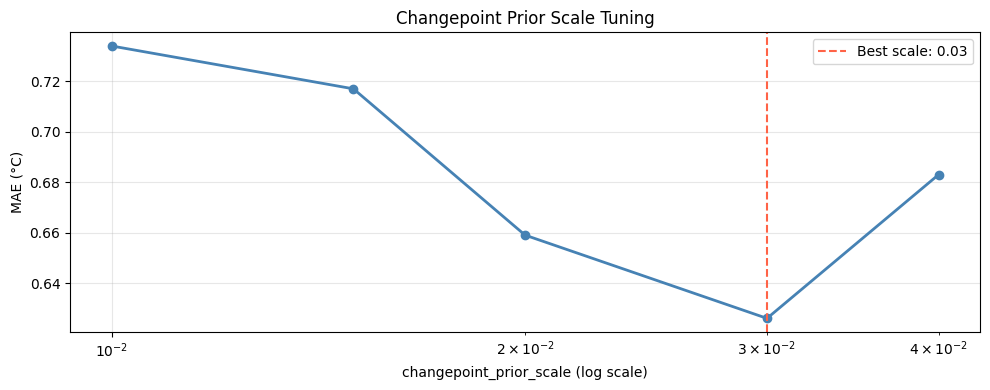

In [24]:
# ── CELL 17: Changepoint Prior Scale Tuning ────────────────────────────────

scales = [ 0.01, 0.015, 0.02, 0.03, 0.04]
tuning_results = []

for scale in scales:
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode=best_mode,
        changepoint_prior_scale=scale,
        seasonality_prior_scale=10,
        interval_width=0.95
    )
    m.fit(train)
    future_temp = m.make_future_dataframe(periods=60)
    fc = m.predict(future_temp)

    merged = test.merge(fc[['ds','yhat']], on='ds', how='left')
    mae  = mean_absolute_error(merged['y'], merged['yhat'])
    rmse = np.sqrt(mean_squared_error(merged['y'], merged['yhat']))
    mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100

    tuning_results.append({
        'changepoint_prior_scale': scale,
        'MAE': round(mae, 3),
        'RMSE': round(rmse, 3),
        'MAPE': round(mape, 2)
    })
    print(f"scale={scale:<6} → MAE: {mae:.3f} | RMSE: {rmse:.3f} | MAPE: {mape:.2f}%")

best_scale = min(tuning_results, key=lambda x: x['MAE'])['changepoint_prior_scale']
print(f"\n✓ Best changepoint_prior_scale: {best_scale}")

# Plot tuning results
scales_list = [r['changepoint_prior_scale'] for r in tuning_results]
maes        = [r['MAE'] for r in tuning_results]

plt.figure(figsize=(10, 4))
plt.plot(scales_list, maes, marker='o', color='steelblue', linewidth=2)
plt.axvline(best_scale, color='tomato', linestyle='--', label=f'Best scale: {best_scale}')
plt.xscale('log')
plt.xlabel('changepoint_prior_scale (log scale)')
plt.ylabel('MAE (°C)')
plt.title('Changepoint Prior Scale Tuning')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tuning_changepoint.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ── CELL 18: Final Tuned Model ────────────────────────────────────────────

print(f"Building final model with:")
print(f"  seasonality_mode      = {best_mode}")
print(f"  changepoint_prior_scale = {best_scale}")
print()

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode=best_mode,
    changepoint_prior_scale=best_scale,
    seasonality_prior_scale=10,
    interval_width=0.95
)

final_model.fit(train)

future_final = final_model.make_future_dataframe(periods=60 + 90)
forecast_final = final_model.predict(future_final)

# Evaluate
test_final = test.merge(
    forecast_final[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds', how='left'
)

mae_final  = mean_absolute_error(test_final['y'], test_final['yhat'])
rmse_final = np.sqrt(mean_squared_error(test_final['y'], test_final['yhat']))
mape_final = np.mean(np.abs((test_final['y'] - test_final['yhat']) / test_final['y'])) * 100

print("=== ORIGINAL MODEL ===")
print(f"  MAE:  0.81°C | RMSE: 1.05°C | MAPE: 4.97%")
print()
print("=== TUNED MODEL ===")
print(f"  MAE:  {mae_final:.2f}°C | RMSE: {rmse_final:.2f}°C | MAPE: {mape_final:.2f}%")
print()

improvement = ((0.81 - mae_final) / 0.81) * 100
if improvement > 0:
    print(f"✓ MAE improved by {improvement:.1f}%")
else:
    print(f"→ Original model was already well-tuned ({abs(improvement):.1f}% difference)")

Building final model with:
  seasonality_mode      = additive
  changepoint_prior_scale = 0.03

=== ORIGINAL MODEL ===
  MAE:  0.81°C | RMSE: 1.05°C | MAPE: 4.97%

=== TUNED MODEL ===
  MAE:  0.63°C | RMSE: 0.78°C | MAPE: 3.81%

✓ MAE improved by 22.7%


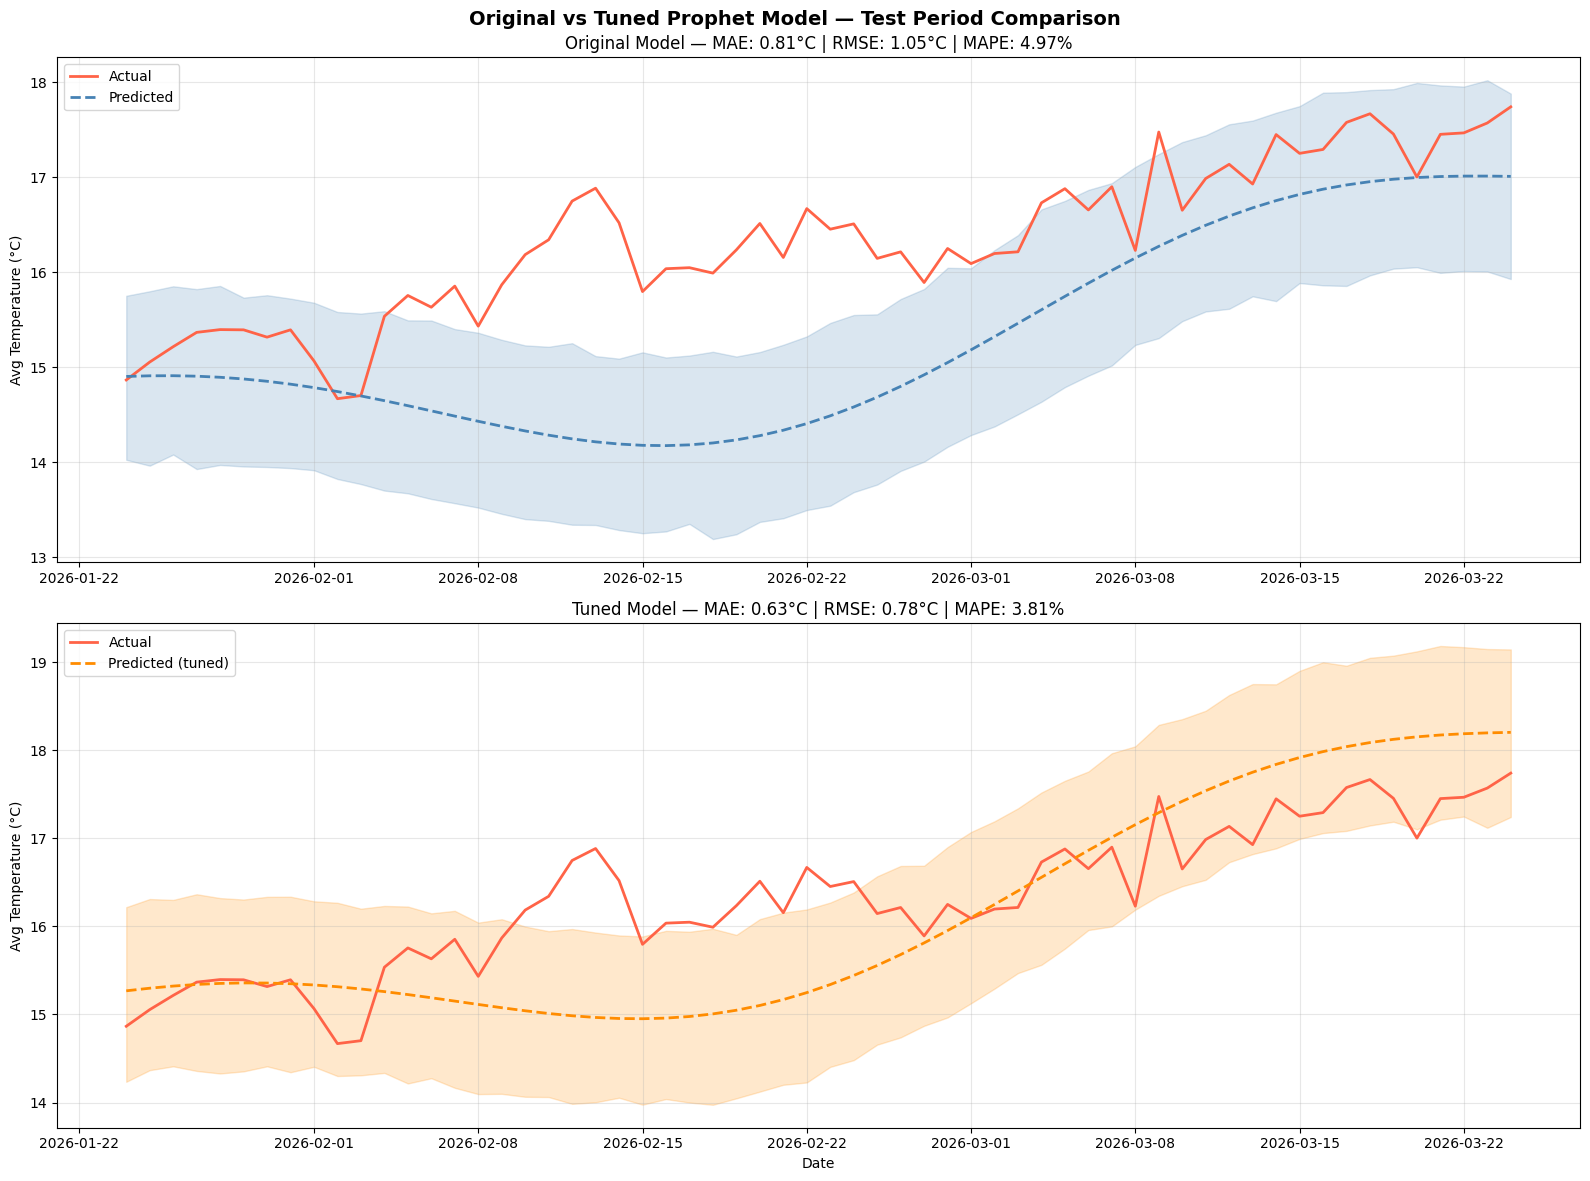

✓ Comparison plot saved


In [26]:
# ── CELL 19: Final Comparison Plot ────────────────────────────────────────

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- Plot 1: Original model on test set ---
test_original = test.merge(
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds', how='left'
)

ax1 = axes[0]
ax1.plot(test_original['ds'], test_original['y'],
         color='tomato', linewidth=2, label='Actual')
ax1.plot(test_original['ds'], test_original['yhat'],
         color='steelblue', linewidth=2, linestyle='--', label='Predicted')
ax1.fill_between(test_original['ds'],
                 test_original['yhat_lower'],
                 test_original['yhat_upper'],
                 alpha=0.2, color='steelblue')
ax1.set_title(f'Original Model — MAE: 0.81°C | RMSE: 1.05°C | MAPE: 4.97%', fontsize=12)
ax1.set_ylabel('Avg Temperature (°C)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# --- Plot 2: Tuned model on test set ---
ax2 = axes[1]
ax2.plot(test_final['ds'], test_final['y'],
         color='tomato', linewidth=2, label='Actual')
ax2.plot(test_final['ds'], test_final['yhat'],
         color='darkorange', linewidth=2, linestyle='--', label='Predicted (tuned)')
ax2.fill_between(test_final['ds'],
                 test_final['yhat_lower'],
                 test_final['yhat_upper'],
                 alpha=0.2, color='darkorange')
ax2.set_title(f'Tuned Model — MAE: {mae_final:.2f}°C | RMSE: {rmse_final:.2f}°C | MAPE: {mape_final:.2f}%', fontsize=12)
ax2.set_ylabel('Avg Temperature (°C)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Original vs Tuned Prophet Model — Test Period Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Comparison plot saved")

In [27]:
# ── CELL 20: Build Daily Dataframe with Regressors ────────────────────────

# Aggregate all features we want as regressors
daily_full = df_clean.groupby(
    df_clean['last_updated'].dt.date
).agg(
    avg_temp      = ('temperature_celsius', 'mean'),
    avg_humidity  = ('humidity',            'mean'),
    avg_pressure  = ('pressure_mb',         'mean'),
    avg_uv        = ('uv_index',            'mean'),
    avg_cloud     = ('cloud',               'mean'),
    avg_wind      = ('wind_kph',            'mean')
).reset_index()

daily_full['last_updated'] = pd.to_datetime(daily_full['last_updated'])

# Remove the same anomalous row we removed before
daily_full = daily_full[daily_full['avg_temp'] >= 10].reset_index(drop=True)

print(f"Shape: {daily_full.shape}")
print(daily_full.head(3))

Shape: (676, 7)
  last_updated   avg_temp  avg_humidity  avg_pressure    avg_uv  avg_cloud  \
0   2024-05-16  23.767196     61.679894   1013.412698  4.986772  37.505291   
1   2024-05-17  24.451648     59.763736   1013.269231  4.021978  34.280220   
2   2024-05-18  25.355610     58.585366   1012.853659  4.960976  34.404878   

    avg_wind  
0  14.686508  
1  13.989560  
2  13.353659  


In [28]:
# ── CELL 21: Check Regressor Correlations with Temperature ────────────────

regressors = ['avg_humidity', 'avg_pressure', 'avg_uv', 'avg_cloud', 'avg_wind']

print("=== Correlation with avg_temp ===")
for col in regressors:
    corr = daily_full['avg_temp'].corr(daily_full[col])
    print(f"  {col:<20} : {corr:+.3f}")

=== Correlation with avg_temp ===
  avg_humidity         : -0.777
  avg_pressure         : -0.522
  avg_uv               : +0.876
  avg_cloud            : -0.526
  avg_wind             : +0.479


In [29]:
# ── CELL 22: Prepare Prophet Dataframe with Regressors ────────────────────

# Rename for Prophet
prophet_reg_df = daily_full.rename(columns={
    'last_updated': 'ds',
    'avg_temp':     'y'
})

# Train/test split — same dates as before
split_date = prophet_reg_df['ds'].max() - pd.Timedelta(days=60)
train_reg  = prophet_reg_df[prophet_reg_df['ds'] <= split_date].copy()
test_reg   = prophet_reg_df[prophet_reg_df['ds'] >  split_date].copy()

print(f"Train: {len(train_reg)} rows | Test: {len(test_reg)} rows")

# For the future dataframe, we need regressor values
# Strategy: use the daily average of each regressor across the full history
# This gives a reasonable baseline for future unknown values
regressor_means = {col: prophet_reg_df[col].mean() for col in regressors}
print("\nRegressor means (used for future dates):")
for k, v in regressor_means.items():
    print(f"  {k:<20}: {v:.2f}")

Train: 616 rows | Test: 60 rows

Regressor means (used for future dates):
  avg_humidity        : 66.50
  avg_pressure        : 1014.09
  avg_uv              : 3.36
  avg_cloud           : 40.02
  avg_wind            : 12.90


In [30]:
# ── CELL 23: Train Prophet with Regressors ────────────────────────────────

model_reg = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.03,
    seasonality_prior_scale=10,
    interval_width=0.95
)

# Add each regressor
for col in regressors:
    model_reg.add_regressor(col)

model_reg.fit(train_reg)
print("✓ Model with regressors trained")

# Build future dataframe
future_reg = model_reg.make_future_dataframe(periods=60 + 90)

# Fill regressors: use actual values where we have them, means for future
for col in regressors:
    # Map actual values from full dataframe
    actual_vals = prophet_reg_df[['ds', col]].set_index('ds')[col]
    future_reg[col] = future_reg['ds'].map(actual_vals)
    # Fill future dates with historical mean
    future_reg[col] = future_reg[col].fillna(regressor_means[col])

forecast_reg = model_reg.predict(future_reg)
print(f"✓ Forecast generated: {forecast_reg.shape}")

✓ Model with regressors trained
✓ Forecast generated: (766, 34)


In [31]:
# ── CELL 24: Evaluate Regressor Model ─────────────────────────────────────

test_reg_forecast = test_reg.merge(
    forecast_reg[['ds', 'yhat', 'yhat_lower', 'yhat_upper']],
    on='ds', how='left'
)

mae_reg  = mean_absolute_error(test_reg_forecast['y'], test_reg_forecast['yhat'])
rmse_reg = np.sqrt(mean_squared_error(test_reg_forecast['y'], test_reg_forecast['yhat']))
mape_reg = np.mean(np.abs((test_reg_forecast['y'] - test_reg_forecast['yhat']) / test_reg_forecast['y'])) * 100

print("=" * 55)
print("         MODEL COMPARISON — FULL SUMMARY")
print("=" * 55)
print(f"{'Model':<25} {'MAE':>7} {'RMSE':>7} {'MAPE':>8}")
print("-" * 55)
print(f"{'Original Prophet':<25} {'0.81':>7} {'1.05':>7} {'4.97%':>8}")
print(f"{'Tuned Prophet':<25} {'0.63':>7} {'0.78':>7} {'3.81%':>8}")
print(f"{'Tuned + Regressors':<25} {mae_reg:>7.2f} {rmse_reg:>7.2f} {mape_reg:>7.2f}%")
print("=" * 55)

best_mae = min(0.81, 0.63, mae_reg)
if mae_reg == best_mae:
    improvement = ((0.81 - mae_reg) / 0.81) * 100
    print(f"\n✓ Regressors model is best — {improvement:.1f}% better than original")
elif mae_reg < 0.63:
    improvement = ((0.63 - mae_reg) / 0.63) * 100
    print(f"\n✓ Regressors improved on tuned model by {improvement:.1f}%")
else:
    print(f"\n→ Tuned model without regressors remains best (MAE: 0.63°C)")

         MODEL COMPARISON — FULL SUMMARY
Model                         MAE    RMSE     MAPE
-------------------------------------------------------
Original Prophet             0.81    1.05    4.97%
Tuned Prophet                0.63    0.78    3.81%
Tuned + Regressors           1.02    1.20    6.22%

→ Tuned model without regressors remains best (MAE: 0.63°C)
